In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from tkinter import Tk
from tkinter.filedialog import askopenfilename

In [2]:
def convert_to_binary_mask(mask_path):
    """Fungsi Step 1: Konversi PNG ke Biner"""
    mask_img = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask_img is None:
        raise ValueError(f"Gambar mask tidak ditemukan di path: {mask_path}")
    
    if mask_img.shape[2] == 4:
        alpha_channel = mask_img[:, :, 3]
        _, binary_mask = cv2.threshold(alpha_channel, 0, 255, cv2.THRESH_BINARY)
    else:
        gray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
        _, binary_mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        
    kernel = np.ones((3,3), np.uint8)
    binary_mask_cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    return binary_mask_cleaned

In [3]:
def resize_image_and_mask(original_img_path, binary_mask, target_width=682, target_height=512):
    """
    Fungsi Step 2: Melakukan resize pada gambar asli dan mask biner
    """
    # 1. Baca gambar asli (mata)
    original_img = cv2.imread(original_img_path)
    if original_img is None:
        raise ValueError(f"Gambar asli tidak ditemukan di path: {original_img_path}")
    
    # Konversi BGR ke RGB untuk visualisasi yang benar
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    # 2. Resize Gambar Asli
    # Menggunakan INTER_LINEAR karena bagus untuk gambar natural (membuatnya tetap halus)
    resized_img = cv2.resize(original_img_rgb, (target_width, target_height), interpolation=cv2.INTER_LINEAR)
    
    # 3. Resize Binary Mask
    # SANGAT PENTING: Menggunakan INTER_NEAREST agar piksel tetap murni 0 atau 255
    # Jika pakai yang lain, tepi mask akan memiliki nilai abu-abu seperti 128, 50, dll.
    resized_mask = cv2.resize(binary_mask, (target_width, target_height), interpolation=cv2.INTER_NEAREST)
    
    return resized_img, resized_mask

In [4]:
def augment_data(image, mask, angle=0, blur_kernel=None, brightness_add=0):
    """
    Fungsi untuk menerapkan augmentasi pada gambar dan mask.
    Sesuai proposal: Angular Rotation, Gaussian Blur, dan Brightness Addition.
    """
    aug_img = image.copy()
    aug_mask = mask.copy()

    # 1. BRIGHTNESS ADDITION (Diterapkan hanya pada gambar asli)
    if brightness_add != 0:
        # Konversi ke float untuk menghindari error batas atas (255)
        img_float = aug_img.astype(np.float32)
        img_float += brightness_add
        # Pangkas nilai agar tetap berada di antara 0 dan 255
        np.clip(img_float, 0, 255, out=img_float)
        aug_img = img_float.astype(np.uint8)

    # 2. GAUSSIAN BLUR (Diterapkan hanya pada gambar asli)
    if blur_kernel is not None:
        aug_img = cv2.GaussianBlur(aug_img, blur_kernel, 0)

    # 3. ANGULAR ROTATION (Diterapkan pada gambar asli DAN mask)
    if angle != 0:
        h, w = aug_img.shape[:2]
        center = (w // 2, h // 2)
        # Buat matriks rotasi
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        
        # Rotasi Gambar (Gunakan INTER_LINEAR agar gambar tetap halus, border direfleksikan agar tidak hitam)
        aug_img = cv2.warpAffine(aug_img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        
        # Rotasi Mask (WAJIB INTER_NEAREST agar nilai piksel mask tetap 0 dan 255)
        aug_mask = cv2.warpAffine(aug_mask, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    return aug_img, aug_mask

In [5]:
def normalize_data(image, mask):
    """
    Fungsi Normalisasi: Mengubah rentang intensitas piksel (0-255)
    menjadi float dengan rentang (0.0 - 1.0) untuk efisiensi model U-Net.
    """
    img_normalized = image.astype(np.float32) / 255.0
    mask_normalized = mask.astype(np.float32) / 255.0
    
    # Karena mask_normalized nilainya hanya 0.0 dan 1.0, 
    # kita tambahkan 1 dimensi di akhir agar bentuknya menjadi (512, 682, 1). 
    # Ini sangat penting karena Keras/TensorFlow mengharapkan input mask berupa 3 dimensi.
    mask_normalized = np.expand_dims(mask_normalized, axis=-1)
    
    return img_normalized, mask_normalized

Ukuran gambar input sekarang: (682, 512, 3)
Ukuran mask input sekarang: (682, 512)
Shape Model Input Image: (682, 512, 3) | Tipe: float32
Shape Model Input Mask:  (682, 512, 1) | Tipe: float32


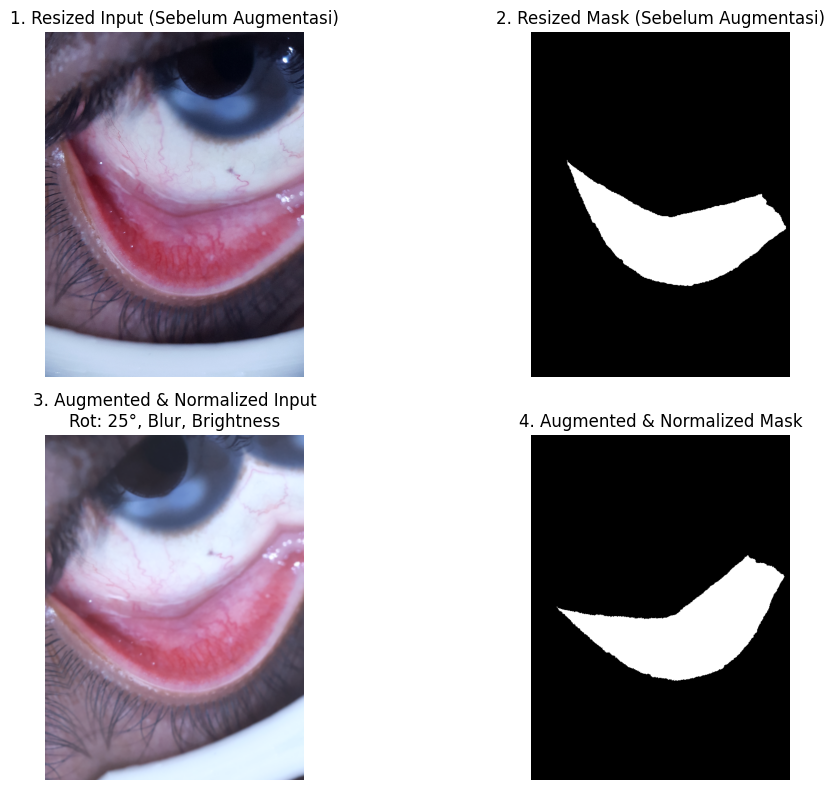

In [6]:
if __name__ == "__main__":
    Tk().withdraw()  # Hide main window

    original_img_filename = askopenfilename(title="Pilih Image")
    mask_filename = askopenfilename(title="Pilih Mask")

    # Nama file dari dataset kamu
    #mask_filename = r'D:\FILE ITS\Keperluan TA\Pra-TA\Dataset\Dataset EyeDefy\India\1\20200118_164733_forniceal_palpebral.png'
    #original_img_filename = r'D:\FILE ITS\Keperluan TA\Pra-TA\Dataset\Dataset EyeDefy\India\1\20200118_164733.jpg'
    
    try:
        # Jalankan Step 1 (Mendapatkan mask biner murni)
        binary_mask_step1 = convert_to_binary_mask(mask_filename)
        
        # Jalankan Step 2 (Resizing)
        # Ingat: format cv2.resize adalah (Width, Height) -> (682, 512)
        resized_image, resized_mask = resize_image_and_mask(original_img_filename, binary_mask_step1, target_width=512, target_height=682)
        
        # Mengecek kebenaran ukuran
        print(f"Ukuran gambar input sekarang: {resized_image.shape}") # Harusnya (512, 682, 3)
        print(f"Ukuran mask input sekarang: {resized_mask.shape}")    # Harusnya (512, 682)
        
        # 3. Lakukan Augmentasi (Simulasi)
        # Sesuai proposal: sudut antara -45 sampai 45 derajat (interval 5 derajat).
        # Di sini kita simulasikan rotasi 25 derajat, dengan sedikit blur dan tambahan brightness.
        test_angle = 25
        test_blur = (5, 5) # Kernel 5x5
        test_brightness = 30 # Menambah kecerahan

        augmented_image, augmented_mask = augment_data(
            resized_image, 
            resized_mask, 
            angle=test_angle, 
            blur_kernel=test_blur, 
            brightness_add=test_brightness
        )

        # 4. Lakukan Normalisasi
        final_img, final_mask = normalize_data(augmented_image, augmented_mask)
        
        # Mengecek bentuk akhir sebelum masuk ke model (Sangat Penting!)
        print(f"Shape Model Input Image: {final_img.shape} | Tipe: {final_img.dtype}")
        print(f"Shape Model Input Mask:  {final_mask.shape} | Tipe: {final_mask.dtype}")

        # 5. Visualisasi Hasil
        plt.figure(figsize=(12, 8))
        
        plt.subplot(2, 2, 1)
        plt.title('1. Resized Input (Sebelum Augmentasi)')
        plt.imshow(resized_image)
        plt.axis('off')
        
        plt.subplot(2, 2, 2)
        plt.title('2. Resized Mask (Sebelum Augmentasi)')
        plt.imshow(resized_mask, cmap='gray')
        plt.axis('off')
        
        plt.subplot(2, 2, 3)
        plt.title(f'3. Augmented & Normalized Input\nRot: {test_angle}°, Blur, Brightness')
        # Matplotlib tetap bisa menampilkan float antara 0.0 - 1.0 dengan benar
        plt.imshow(final_img) 
        plt.axis('off')
        
        plt.subplot(2, 2, 4)
        plt.title('4. Augmented & Normalized Mask')
        # Hilangkan dimensi terakhir (yang ukurannya 1) hanya untuk keperluan visualisasi
        plt.imshow(np.squeeze(final_mask), cmap='gray')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Terjadi kesalahan: {e}")